# Visual Anagrams

Zero-shot method for obtaining these illusions from off-the-shelf text-to-image diffusion models. During the reverse diffusion process, we estimate the noise from different views of a noisy image, and then combine these noise estimates together and denoise the image. A theoretical analysis suggests that this method works precisely for views that can be written as orthogonal transformations, of which permutations are a subset. This leads to the idea of a visual anagram--an image that changes appearance under some rearrangement of pixels. This includes rotations and flips, but also more exotic pixel permutations such as a jigsaw rearrangement. 

## Setup and imports

In [1]:
!pip install -q --upgrade transformers diffusers ftfy accelerate matplotlib torchvision scipy

In [2]:
!pip install sentencepiece

In [3]:
from base64 import b64encode

import numpy
import torch
from diffusers import StableDiffusionXLPipeline
from huggingface_hub import notebook_login

# For video display:
from IPython.display import HTML
from matplotlib import pyplot as plt
from pathlib import Path
from PIL import Image
from torch import autocast
from torchvision import transforms as tfms
from tqdm.auto import tqdm
from transformers import CLIPTextModel, CLIPTokenizer, logging
from torchvision.transforms import v2
import os

torch.manual_seed(1)
if not (Path.home()/'.cache/huggingface'/'token').exists(): notebook_login()

# Supress some unnecessary warnings when loading the CLIPTextModel
logging.set_verbosity_error()

# Set device
torch_device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
if "mps" == torch_device: os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = "1"

/Users/ricardomatos/.pyenv/versions/3.9.18/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ricardomatos/.pyenv/versions/3.9.18/lib/python3.9/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


## Loading Models

The authors mention that they use a pixel-based diffusion model, because latent diffusion contained some artifacts. Let's ignore that. 

In [22]:
from diffusers import StableDiffusionXLPipeline
from diffusers.pipelines.stable_diffusion_xl.pipeline_output import StableDiffusionXLPipelineOutput
import torch

class TrSDXLPipeline(StableDiffusionXLPipeline):

    @torch.no_grad()
    def __call__(
        self,
        prompts,
        prompts_2=None,
        negative_prompts=None,
        negative_prompts_2=None,
        height=None,
        width=None,
        num_inference_steps=50,
        guidance_scale=5.0,
        num_images_per_prompt=1,
        eta=0.0,
        generator=None,
        latents=None,
        output_type="pil",
        anagram_transformation=None
    ):
        device = self._execution_device
        height = height or self.default_sample_size * self.vae_scale_factor
        width = width or self.default_sample_size * self.vae_scale_factor
        batch_size = num_images_per_prompt # For simplicity, let's consider the num_images_per_prompt for the batch_size, the naming is not the most correct though
        do_cfg = guidance_scale > 1 and self.unet.config.time_cond_proj_dim is None

        list_prompt_embeds = []
        list_cond_kwargs = []
        for i in range(len(prompts)):
            prompt = prompts[i]
            prompt_2 = prompts[i]

            negative_prompt = negative_prompts[i] if negative_prompts else None
            negative_prompt_2 = negative_prompts_2[i] if negative_prompts_2 else None
            # 1. Encode prompts with both text encoders (token embeds + pooled embeds)
            prompt_embeds, negative_prompt_embeds, pooled_embeds, negative_pooled_embeds = self.encode_prompt(
                prompt=prompt,
                prompt_2=prompt_2,
                device=device,
                num_images_per_prompt=num_images_per_prompt,
                do_classifier_free_guidance=do_cfg,
                negative_prompt=negative_prompt,
                negative_prompt_2=negative_prompt_2,
            )

            # 2. SDXL micro-conditioning: (original_size, crop_top_left, target_size)
            add_time_ids = self._get_add_time_ids(
                (height, width), (0, 0), (height, width),
                dtype=prompt_embeds.dtype,
                text_encoder_projection_dim=self.text_encoder_2.config.projection_dim,
            )

            # For CFG, batch [uncond, cond] so the unet runs once per step
            if do_cfg:
                prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds])
                pooled_embeds = torch.cat([negative_pooled_embeds, pooled_embeds])
                add_time_ids = torch.cat([add_time_ids, add_time_ids])
            prompt_embeds = prompt_embeds.to(device)
            added_cond_kwargs = {
                "text_embeds": pooled_embeds.to(device),
                "time_ids": add_time_ids.to(device).repeat(batch_size, 1),
            }

            list_prompt_embeds.append(prompt_embeds)
            list_cond_kwargs.append(added_cond_kwargs)

        # 3. Timesteps and initial noise
        self.scheduler.set_timesteps(num_inference_steps, device=device)
        timesteps = self.scheduler.timesteps
        latents = self.prepare_latents(
            batch_size, self.unet.config.in_channels, height, width,
            prompt_embeds[0].dtype, device, generator, latents,
        )
        extra_step_kwargs = self.prepare_extra_step_kwargs(generator, eta)

        # 4. Denoising loop
        for t in self.progress_bar(timesteps):
            latent_model_input = torch.cat([latents] * 2) if do_cfg else latents
            latent_model_input = self.scheduler.scale_model_input(latent_model_input, t)

            noise_preds = []
            for i in range(len(prompts)):
                # Look at the noisy image through view i
                view_input = anagram_transformation(latent_model_input, i) if anagram_transformation else latent_model_input

                noise_pred = self.unet(
                    view_input,
                    t,
                    encoder_hidden_states=list_prompt_embeds[i],
                    added_cond_kwargs=list_cond_kwargs[i],
                    return_dict=False,
                )[0]

                if do_cfg:
                    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

                # Undo the view so every prediction is in the same orientation before averaging
                if anagram_transformation:
                    noise_pred = anagram_transformation(noise_pred, i, inverse=True)
                noise_preds.append(noise_pred)

            noise_pred = torch.stack(noise_preds).mean(dim=0)

            latents_dtype = latents.dtype
            latents = self.scheduler.step(noise_pred, t, latents, **extra_step_kwargs, return_dict=False)[0]
            # Some schedulers upcast on mps, bring back to the original dtype
            if latents.dtype != latents_dtype and torch.backends.mps.is_available():
                latents = latents.to(latents_dtype)

        if output_type == "latent":
            self.maybe_free_model_hooks()
            return StableDiffusionXLPipelineOutput(images=latents)

        # 5. Decode latents. The SDXL VAE overflows in fp16, so decode in fp32
        needs_upcasting = self.vae.dtype == torch.float16 and self.vae.config.force_upcast
        if needs_upcasting:
            self.upcast_vae()
            latents = latents.to(next(iter(self.vae.post_quant_conv.parameters())).dtype)
        elif latents.dtype != self.vae.dtype and torch.backends.mps.is_available():
            self.vae = self.vae.to(latents.dtype)

        image = self.vae.decode(latents / self.vae.config.scaling_factor, return_dict=False)[0]

        if needs_upcasting:
            self.vae.to(dtype=torch.float16)

        if self.watermark is not None:
            image = self.watermark.apply_watermark(image)
        image = self.image_processor.postprocess(image, output_type=output_type)

        self.maybe_free_model_hooks()
        return StableDiffusionXLPipelineOutput(images=image)

In [23]:
pipe = TrSDXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

Keyword arguments {'trust_remote_code': True} are not expected by TrSDXLPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 7/7 [00:15<00:00,  2.28s/it]


In [24]:
pipe.to(torch_device)

TrSDXLPipeline {
  "_class_name": "TrSDXLPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "stabilityai/stable-diffusion-xl-base-1.0",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [ ]:
def anagram_view(x, i, inverse=False, steps = [0, 2]):
    # view 0: identity, view 1: rotated 180 degrees
    k = steps[i]
    return torch.rot90(x, -k if inverse else k, dims=(-2, -1))

image = pipe(["A person", "A cat"], num_inference_steps=30, guidance_scale=11, anagram_transformation=anagram_view)

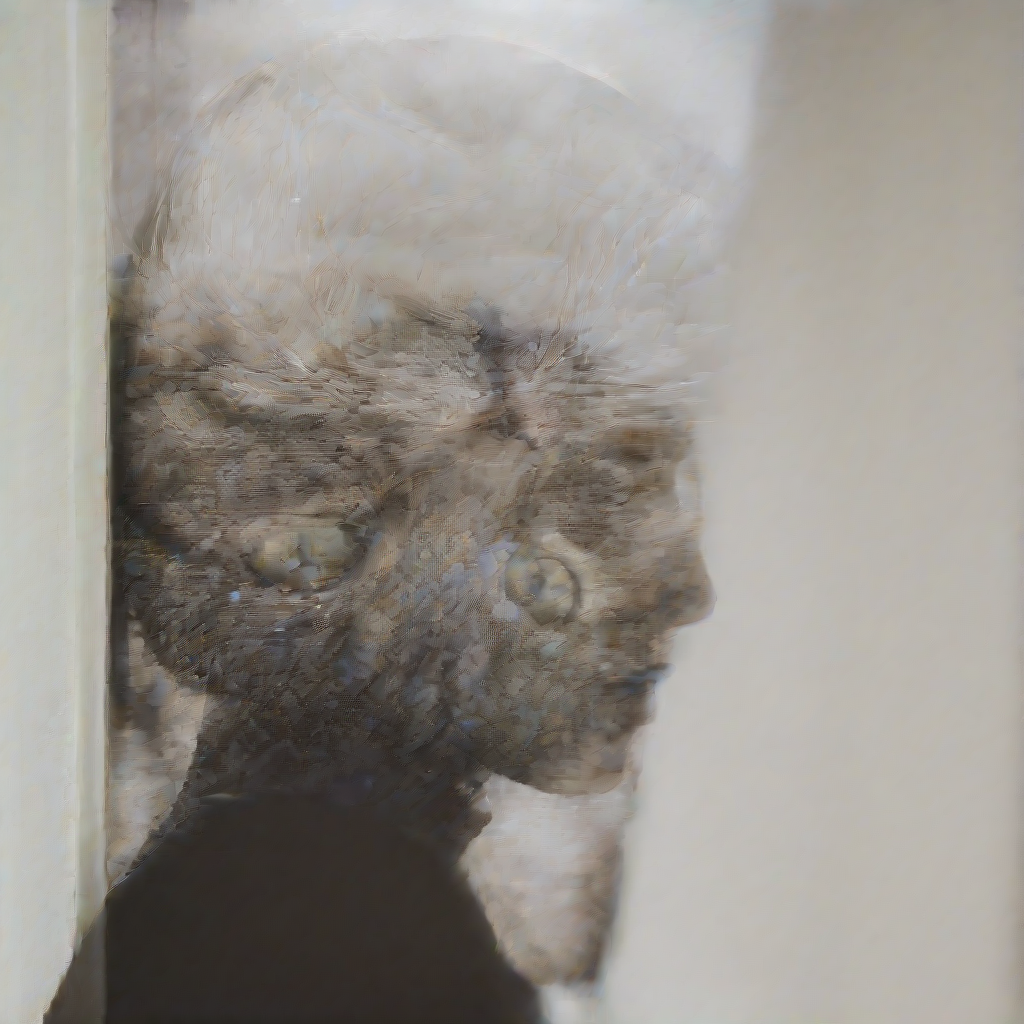

In [44]:
image.images[0]

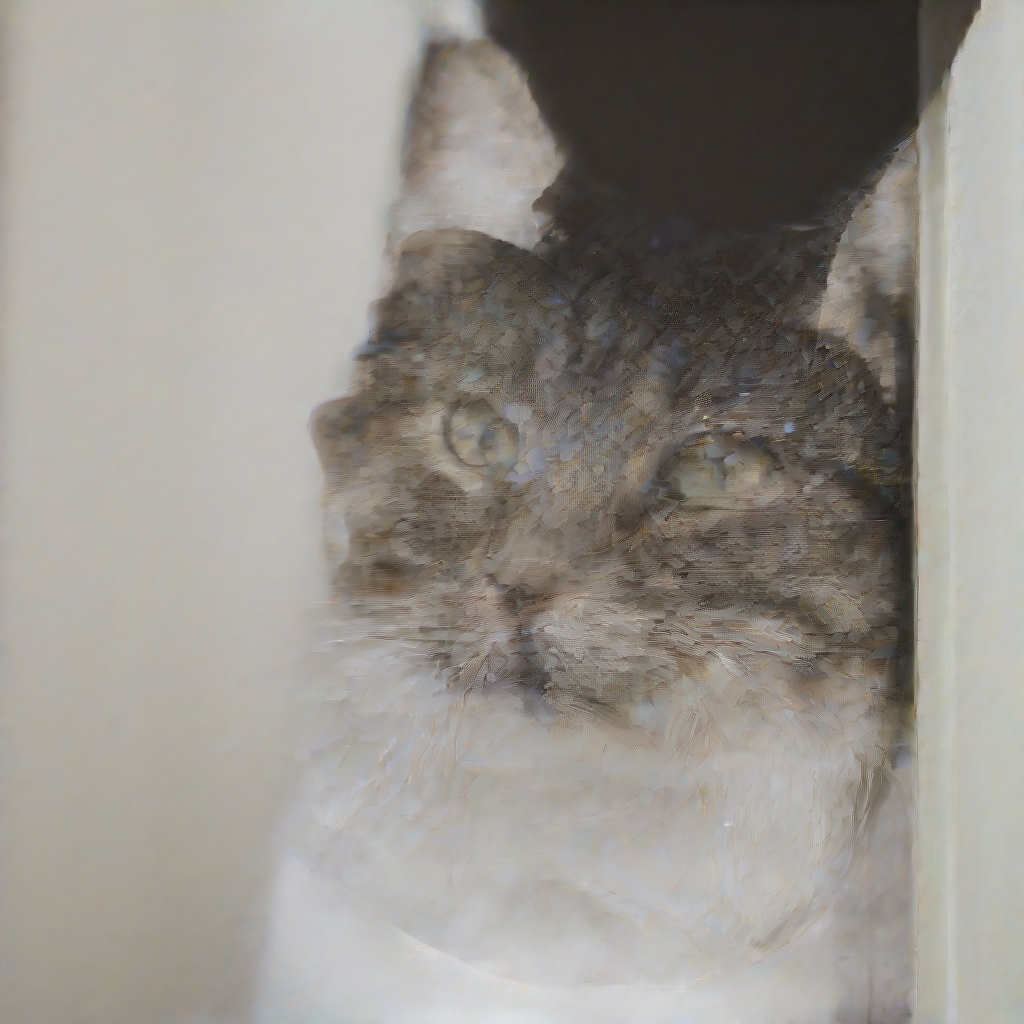

In [45]:
image.images[0].rotate(180)

Now, four view anagram

In [30]:
prompts = ["A person", "A cat", "A dog", "A Penguin"]
image = pipe(prompts, num_inference_steps=30, guidance_scale=11, anagram_transformation=lambda x, i, inverse=False: anagram_view(x, i, inverse=inverse, steps=[0, 1, 2, 3]))

100%|██████████| 30/30 [02:51<00:00,  5.71s/it]


0
1
2
3


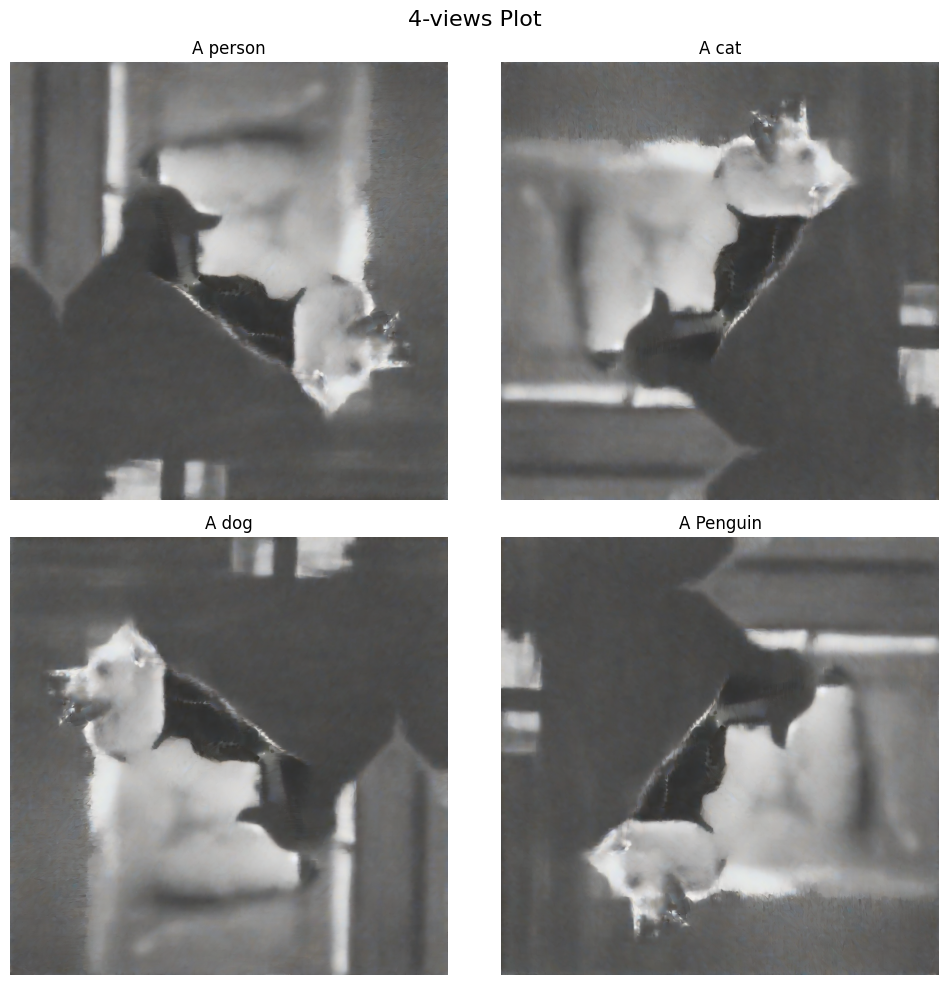

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("4-views Plot", fontsize=16)

for i, ax in enumerate(axes.flat):
    print(i)
    ax.imshow(image.images[0].rotate(90 * i))
    ax.axis("off")  # Hide axes
    ax.set_title(f"{prompts[i]}")

plt.tight_layout()
plt.show()


Now, a negative image. Let's use negative prompting, the paper mentions it provides best results.

In [70]:
def anagram_view(x, i, inverse=False, steps = [0, 2]):
    k = steps[i]
    return - x if k > 0 else x

prompts = [
    "a photo of a man, clear face, no background",
    "a photo of a woman, clear face, no background",
]
negative_prompt = "blurry, low quality, distorted, bad anatomy, artifacts"
negative_prompts = [negative_prompt + ", woman", negative_prompt + ", man"] 

image = pipe(prompts, negative_prompts = prompts[::-1], num_inference_steps=60, guidance_scale=40, anagram_transformation=lambda x, i, inverse=False: anagram_view(x, i, inverse=inverse, steps=[0, 1]))

100%|██████████| 60/60 [02:50<00:00,  2.84s/it]


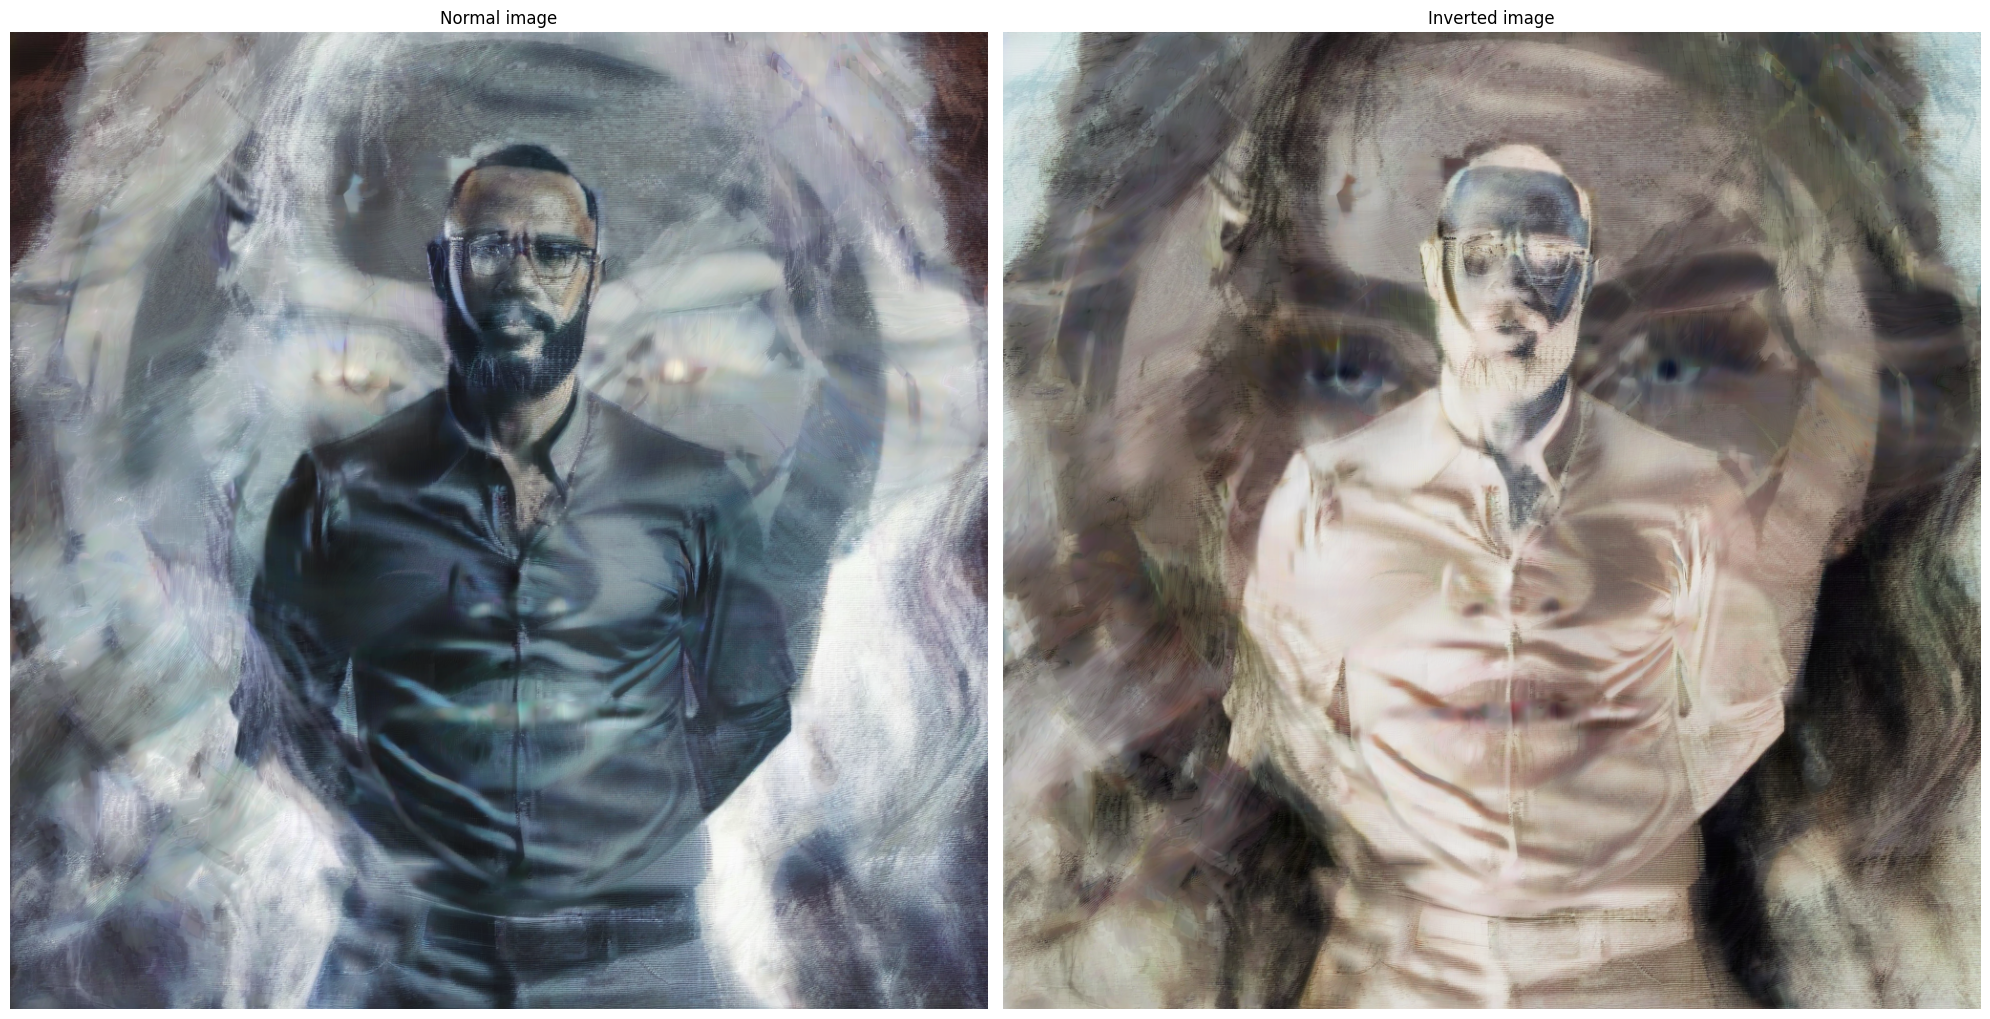

In [71]:
from PIL import ImageOps

fig, axes = plt.subplots(1, 2, figsize=(20,20))

axes[0].imshow(image.images[0])
axes[0].axis("off")
axes[0].set_title("Normal image")

axes[1].imshow(ImageOps.invert(image.images[0]))
axes[1].axis("off")
axes[1].set_title("Inverted image")

plt.tight_layout()
plt.show()